## Segmented Modeling and Mixture of Experts

### Notebook Objectives
- Apply a segmented modeling approach across different price segments
- Train specialized expert models for individual price segments
- Implement a Mixture of Experts (MoE) approach to combine segment-specific predictions
- Evaluate the MoE against the baseline model established in Notebook 03

In [1]:
# Projekt-Root zum Pfad hinzufügen
import sys
sys.path.append("..") # damit src/ Module gefunden werden

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from src.train_model import get_train_test_data, create_model_pipeline
from src.evaluate import load_model, compute_metrics
from src.moe import create_expert_model, predict_with_hard_routing

In [3]:
# Lade Trainings- und Testdaten
X_train, X_test, y_train, y_test = get_train_test_data()

# Lade das Baseline-Modell aus Notebook 03
baseline_model = load_model("rf_log")

print(f"Beobachtungen Trainingsdaten: {len(X_train)}")
print(f"Beobachtungen Testdaten:      {len(X_test)}")

Modell geladen: rf_log (models/rf_log_pipeline.pkl)
Beobachtungen Trainingsdaten: 12000
Beobachtungen Testdaten:      3000


## Baseline Model

The Random Forest with log-transformed target was identified as the best-performing model in Notebook 03 based on RMSE.

It serves as the baseline for evaluating whether price-segment-specific expert models and the resulting Mixture of Experts can improve prediction performance.

In [4]:
# Generiere Baseline-Vorhersagen
y_pred_baseline = np.expm1(baseline_model.predict(X_test))

# Evaluiere Baseline-Modell
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline-Performance (RF (Log-Target))")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"MAE:  {baseline_mae:.2f}")
print(f"R2:   {baseline_r2:.4f}")

Baseline-Performance (RF (Log-Target))
RMSE: 64.77
MAE:  43.75
R2:   0.3780


## Price Segmentation

Before defining the price segments, the distribution of the target variable in the training data is examined.

The segmentation boundaries will be derived exclusively from the training data to avoid information leakage.

Beschreibende Statistik der Preisverteilung in den Trainingsdaten:



count    12000.000000
mean       153.298750
std         84.035695
min         21.000000
25%         94.000000
50%        131.000000
75%        186.000000
max        500.000000
Name: price, dtype: float64


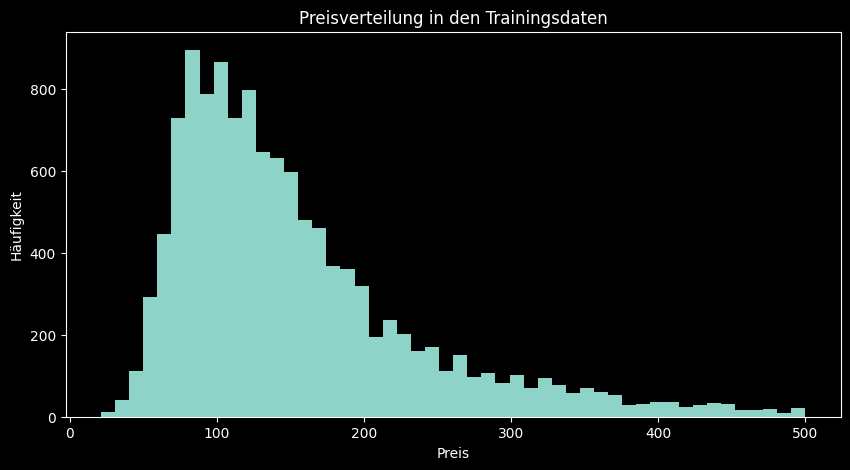

In [5]:
# Untersuche die Preisverteilung in den Trainingsdaten
print("Beschreibende Statistik der Preisverteilung in den Trainingsdaten:\n")
print(y_train.describe())

plt.figure(figsize=(10, 5))

plt.hist(y_train, bins=50)

plt.xlabel("Preis")
plt.ylabel("Häufigkeit")
plt.title("Preisverteilung in den Trainingsdaten")

plt.show()

### Define Price Segments

Three price segments are defined based on the 33rd and 66th percentiles of the training target distribution.

The boundaries are calculated exclusively from the training data to prevent information leakage.

In [6]:
# Definiere Preis-Segmente auf Basis der Trainingsdaten
q33 = y_train.quantile(1/3)
q66 = y_train.quantile(2/3)

print(f"33%-Quantil: {q33:.2f}")
print(f"66%-Quantil: {q66:.2f}")

# Ordne die Beoobachungen in den Trainingsdaten den Preis-Segmenten zu
train_segments = pd.cut(
    y_train, 
    bins=[-np.inf, q33, q66, np.inf], 
    labels=["low", "mid", "high"]
)

print("\nAnzahl Beobachtungen pro Preis-Segment in den Trainingsdaten:")
print(train_segments.value_counts().sort_index())

print("\nProzentuale Verteilung der Preis-Segmente in den Trainingsdaten:")
print(train_segments.value_counts(normalize=True).sort_index())

33%-Quantil: 105.00
66%-Quantil: 163.00

Anzahl Beobachtungen pro Preis-Segment in den Trainingsdaten:
price
low     4028
mid     3998
high    3974
Name: count, dtype: int64

Prozentuale Verteilung der Preis-Segmente in den Trainingsdaten:
price
low     0.335667
mid     0.333167
high    0.331167
Name: proportion, dtype: float64


### Create Training Segments

The training data is split into three price segments using the previously defined boundaries.

Each segment contains the same feature set as the baseline model, but the expert models will only be trained on observations belonging to their respective price segment.

In [7]:
# Erstelle Boolean-Masks für jedes Preis-Segment   
train_low_mask = train_segments == "low"
train_mid_mask = train_segments == "mid"
train_high_mask = train_segments == "high"

# Erstelle segmentspezifische Trainingsdaten
X_train_low = X_train[train_low_mask]
y_train_low = y_train[train_low_mask]

X_train_mid = X_train[train_mid_mask]
y_train_mid = y_train[train_mid_mask]

X_train_high = X_train[train_high_mask]
y_train_high = y_train[train_high_mask]

# Prüfe Segmentgrößen
print("Segmentgrößen:")
print(f"Low:    {len(X_train_low)} Beobachtungen")
print(f"Mid:    {len(X_train_mid)} Beobachtungen")
print(f"High:   {len(X_train_high)} Beobachtungen")

Segmentgrößen:
Low:    4028 Beobachtungen
Mid:    3998 Beobachtungen
High:   3974 Beobachtungen


## Train Expert Models

Each expert model uses the same Random Forest architecture as the baseline model, but is trained exclusively on observations from its respective price segment.

The target variable is log-transformed consistently with the baseline model.

In [8]:
# Erstelle Experten-Modelle für jedes Preis-Segment
expert_low = create_model_pipeline(create_expert_model())
expert_mid = create_model_pipeline(create_expert_model())
expert_high = create_model_pipeline(create_expert_model())


# Trainiere Low-Price-Experte
expert_low.fit(X_train_low, np.log1p(y_train_low))

# Trainiere Mid-Price-Experte
expert_mid.fit(X_train_mid, np.log1p(y_train_mid))

# Trainiere High-Price-Experte
expert_high.fit(X_train_high, np.log1p(y_train_high))

print("\nExperten-Modelle wurden erfolgreich trainiert.")
print(f"Low-Price-Experte: {len(X_train_low)} Beobachtungen")
print(f"Mid-Price-Experte: {len(X_train_mid)} Beobachtungen")
print(f"High-Price-Experte: {len(X_train_high)} Beobachtungen")




Experten-Modelle wurden erfolgreich trainiert.
Low-Price-Experte: 4028 Beobachtungen
Mid-Price-Experte: 3998 Beobachtungen
High-Price-Experte: 3974 Beobachtungen


## Evaluate Expert Models

The expert models are first evaluated under oracle segmentation, where the actual price segment of each test observation is known.

This isolates the potential benefit of segment-specific modeling before introducing a predictive routing mechanism.

In [9]:
# Ordne die Beobachtungen in den Testdaten den Preis-Segmenten zu
test_segments = pd.cut(
    y_test, 
    bins=[-np.inf, q33, q66, np.inf], 
    labels=["low", "mid", "high"]
)   

print("\nAnzahl Beobachtungen pro Preis-Segment in den Testdaten:")
print(test_segments.value_counts().sort_index())


Anzahl Beobachtungen pro Preis-Segment in den Testdaten:
price
low     1003
mid     1025
high     972
Name: count, dtype: int64


In [10]:
# Erstelle Boolean-Masks für jedes Preis-Segment in den Testdaten
test_low_mask = test_segments == "low"
test_mid_mask = test_segments == "mid"
test_high_mask = test_segments == "high"

# Generiere Vorhersagen für jedes Preis-Segment
y_pred_expert = pd.Series(index=y_test.index, dtype=float)

y_pred_expert.loc[test_low_mask] = np.expm1(expert_low.predict(X_test[test_low_mask]))

y_pred_expert.loc[test_mid_mask] = np.expm1(expert_mid.predict(X_test[test_mid_mask]))

y_pred_expert.loc[test_high_mask] = np.expm1(expert_high.predict(X_test[test_high_mask]))

print(f"Generierte Vorhersagen: {y_pred_expert.notna().sum()}")
print(f"Fehlende Vorhersagen: {y_pred_expert.isna().sum()}")


Generierte Vorhersagen: 3000
Fehlende Vorhersagen: 0


In [11]:
# Evaluiere die Vorhersagen der Experten-Modelle
experts_rmse = np.sqrt(mean_squared_error(y_test, y_pred_expert))

experts_mae = mean_absolute_error(y_test, y_pred_expert)

experts_r2 = r2_score(y_test, y_pred_expert)

print("\nExperten-Modelle Performance:")
print(f"RMSE: {experts_rmse:.2f}")
print(f"MAE:  {experts_mae:.2f}")
print(f"R2:   {experts_r2:.4f}")

rmse_improvement = (baseline_rmse - experts_rmse) / baseline_rmse * 100

print(f"\nRMSE-Verbesserung gegenüber Baseline: {rmse_improvement:.2f}%")


Experten-Modelle Performance:
RMSE: 44.86
MAE:  26.77
R2:   0.7016

RMSE-Verbesserung gegenüber Baseline: 30.73%


In [12]:
# Segmentweise Evaluation der Experten-Modelle

segment_results = {}

for segment, mask in {
    "low": test_low_mask,
    "mid": test_mid_mask,
    "high": test_high_mask
}.items():
    
    segment_results[segment] = compute_metrics(
        y_test.loc[mask], 
        y_pred_expert.loc[mask]
    )

segment_results_df = pd.DataFrame(segment_results).T.round(2)

segment_results_df

,rmse,mae,r2
low,14.07,11.30,0.26
mid,16.34,13.63,0.05
high,75.68,56.60,0.03


### Baseline vs. Expert Models by Price Segment

To assess the benefit of specialization, the baseline model and the corresponding expert model are compared within each price segment.

In [13]:
y_pred_baseline = pd.Series(y_pred_baseline, index=y_test.index)

segment_comparison = {}

for segment, mask in {
    "low": test_low_mask,
    "mid": test_mid_mask,
    "high": test_high_mask
}.items():

    baseline_metrics = compute_metrics(y_test.loc[mask], y_pred_baseline.loc[mask])

    expert_metrics = compute_metrics(y_test.loc[mask], y_pred_expert.loc[mask])

    segment_comparison[segment] = {
        "Baseline_RMSE": baseline_metrics["rmse"],
        "Expert_RMSE": expert_metrics["rmse"],
        "RMSE_Improvement_%": (
            (baseline_metrics["rmse"] - expert_metrics["rmse"]) 
            / baseline_metrics["rmse"] 
            * 100
            ),
    }
        
segment_comparison_df = pd.DataFrame(segment_comparison).T.round(2)

segment_comparison_df

,Baseline_RMSE,Expert_RMSE,RMSE_Improvement_%
low,35.34,14.07,60.20
mid,41.60,16.34,60.73
high,99.17,75.68,23.69


## Intermediate Conclusion

- Segment-specific Random Forest models outperform the global RF baseline across all price segments
- The strongest improvements are observed in the low- and mid-price segments
- The high-price segment also benefits from specialization, although prediction errors remain substantially higher
- The results indicate that price segmentation has the potential to improve prediction performance
- A predictive routing mechanism is therefore required to assess whether these gains can be achieved without access to the true target

## Segment Characteristics

Before training the routing model, the characteristics of the three price segments are compared to identify systematic differences in their feature distributions.

In [14]:
segment_analysis = X_train.copy()
segment_analysis["price_segment"] = train_segments.values

segment_analysis.groupby(
    "price_segment",
    observed=True
)[
    [
        "minimum_nights",
        "number_of_reviews",
        "review_scores_rating",
        "latitude",
        "longitude",
        "amenity_count",
    ]
].mean().round(2).T

price_segment,low,mid,high
minimum_nights,1.97,1.88,1.90
number_of_reviews,64.21,67.55,64.87
review_scores_rating,4.79,4.79,4.80
latitude,41.88,41.89,41.90
longitude,12.48,12.48,12.48
amenity_count,34.19,34.53,35.63


In [15]:
pd.crosstab(
    segment_analysis["price_segment"], 
    segment_analysis["room_type"], 
    normalize="index"
).round(2).T

price_segment,low,mid,high
room_type,,,
Entire home/apt,0.68,0.80,0.87
Hotel room,0.00,0.01,0.00
Private room,0.31,0.19,0.12
Shared room,0.00,0.00,0.00


### Interpretation

- The numerical feature distributions show only minor differences across the three price segments
- `room_type` exhibits a clearer relationship with price segments, with entire homes/apartments becoming more prevalent at higher price levels
- While no single feature clearly separates the segments, the combination of multiple features may still provide sufficient information for segment prediction
- A Random Forest classifier is therefore used as a routing model to predict the most likely price segment for new listings

## Price Segment Router

A Random Forest classifier is used as a routing model to predict the price segment of a new listing based on its available features.

The routing target is derived from the training prices using the previously defined segment boundaries.

In [16]:
# Erstelle das Zielvariable des Routing-Modells basierend auf den Preis-Segmenten der Trainingsdaten
y_train_segment = train_segments

print("Verteilung der Routing-Zielvariable (Preis-Segmente) in den Trainingsdaten:")
print(y_train_segment.value_counts().sort_index())

Verteilung der Routing-Zielvariable (Preis-Segmente) in den Trainingsdaten:
price
low     4028
mid     3998
high    3974
Name: count, dtype: int64


### Train the Routing Model

The router uses the same feature preprocessing as the regression modells and is trained to classify listings into the three price segments.

In [17]:
# Erstelle und trainiere die Router-Pipeline

rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

router = create_model_pipeline(rf_classifier)

router.fit(X_train, y_train_segment)

print("\nRouter-Pipeline wurde erfolgreich trainiert.")


Router-Pipeline wurde erfolgreich trainiert.


### Evaluate the Routing Model

The router is evaluated on the test data using actual price segments as reference labels.

This evaluation measures how reliably the routing model can identify the appropriate price segment without access to the target value during prediction.

In [18]:
# Vorhersage der Preis-Segmente für die Testdaten
y_test_pred_segment = router.predict(X_test)

# Evaluierung der Genaugkeit des Routing-Modells
accuracy = accuracy_score(test_segments, y_test_pred_segment)
classification_rep = classification_report(test_segments, y_test_pred_segment)

labels = ["low", "mid", "high"]
cm = confusion_matrix(test_segments, y_test_pred_segment, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"actual {label}" for label in labels], columns=[f"predicted {label}" for label in labels])

print(f"\nRouting-Modell Genauigkeit: {accuracy:.3f}")

print("\nKlassifikationsbericht:")
print(classification_rep)

print("\nKonfusionsmatrix:")
print(cm_df)


Routing-Modell Genauigkeit: 0.597

Klassifikationsbericht:
              precision    recall  f1-score   support

        high       0.63      0.67      0.65       972
         low       0.67      0.71      0.69      1003
         mid       0.47      0.41      0.44      1025

    accuracy                           0.60      3000
   macro avg       0.59      0.60      0.59      3000
weighted avg       0.59      0.60      0.59      3000


Konfusionsmatrix:
             predicted low  predicted mid  predicted high
actual low             714            227              62
actual mid             278            422             325
actual high             78            240             654


### Interpretation

- The Random Forest router achieves an overall accuracy of approximately 60%
- Low- and high-price listings are classified more reliably than mid-price listings
- The mid-price segment is frequently confused with both low- and high-price segments
- The moderate routing accuracy indicates that the gains of the expert models may not be fully retained in a realistic Mixture of Experts setup
- The actual MoE performance is therefore evaluated using the router's predicted segments

### Generate Mixture of Experts Predictions using Hard Routing

The trained router assigns each test observation to exactly one of the three price segments (hard routing). The corresponding expert model then generates the final price prediction that observation.

In [19]:
y_pred_moe = predict_with_hard_routing(X_test, router, expert_low, expert_mid, expert_high)

print(f"Vorhersagen mit Mixture of Experts generiert:\n{y_pred_moe.head()}")
print(f"\nAnzahl generierter Vorhersagen: {len(X_test)}")
print(f"Anzahl erfolgreicher Vorhersagen: {y_pred_moe.notna().sum()}")
print(f"Anzahl fehlender Vorhersagen: {y_pred_moe.isna().sum()}")


Vorhersagen mit Mixture of Experts generiert:
11499    256.840472
6475     123.116794
13167    133.627595
862      246.815794
5970     136.251652
dtype: float64

Anzahl generierter Vorhersagen: 3000
Anzahl erfolgreicher Vorhersagen: 3000
Anzahl fehlender Vorhersagen: 0


### Evaluate the Hard-Routing MoE

The performance of the hard-routing Mixture of Experts is evaluated using RMSE, MAE, and R² and compared with the global RF baseline and the oracle expert models.

In [20]:
moe_metrics = compute_metrics(y_test, y_pred_moe)

print("Mixture of Experts Metriken:\n")
print(f"RMSE: {moe_metrics['rmse']:.2f}")
print(f"MAE: {moe_metrics['mae']:.2f}")
print(f"R2: {moe_metrics['r2']:.4f}")

Mixture of Experts Metriken:

RMSE: 71.80
MAE: 50.25
R2: 0.2358


### Routing Error Analysis

The hard-routing MoE does not outperform the global RF baseline, despite the substantial performance gains observed under oracle routing.

This suggests that routing errors may offset the benefits of the specialized expert models.

The following analysis compares prediction errors for correctly and incorrectly routed observations to assess the impact of routing accuracy on overall MoE performance.

In [21]:
routing_analysis = pd.DataFrame({
    "actual_segment": test_segments,
    "predicted_segment": router.predict(X_test),
    "y_true": y_test,
    "y_pred": y_pred_moe
})

routing_analysis["routing_correct"] = routing_analysis["actual_segment"] == routing_analysis["predicted_segment"]
routing_analysis["absolute_error"] = (routing_analysis["y_true"] - routing_analysis["y_pred"]).abs()

routing_analysis.groupby("routing_correct")["absolute_error"].agg(["mean", "median", "std"]).round(2)

,mean,median,std
routing_correct,,,
False,80.37,66.41,53.12
True,29.89,15.88,38.39


### Routing Error by Segment

The previous analysis shows that incorrect routing is associated with substantially higher prediction errors.

The next analysis examines which specific routing errors contribute most to the MoE's performance loss.

In [22]:
routing_analysis.groupby(
    ["actual_segment", "predicted_segment"],
      observed=True)["absolute_error"].agg(
          ["count", "mean", "median"]
).round(2)

count    mean  median
actual_segment predicted_segment                       
low            high                  62  138.11  138.25
               low                  714   11.51    9.69
               mid                  227   42.36   42.40
mid            high                 325   99.21   98.83
               low                  278   45.11   41.67
               mid                  422   13.84   12.99
high           high                 654   60.33   49.04
               low                   78  150.50  126.09
               mid                  240   93.94   71.03

In [23]:
routing_performance = routing_analysis.groupby(
    "routing_correct",
    observed=True
).apply(
    lambda group: pd.Series(
        compute_metrics(
            group["y_true"],
            group["y_pred"]
        )
    ),
    include_groups=False
).round(2)

routing_performance = routing_performance[["rmse", "mae"]]

routing_performance

,rmse,mae
routing_correct,,
False,96.32,80.37
True,48.65,29.89


Incorrectly routed listings exhibit substantially higher prediction errors than correctly routed listings. This indicates that routing errors are a major factor limiting the performance of the hard-routing MoE.

## Final Model Comparison

In [24]:
# Berechne Metriken für jeden Modelltyp
baseline_metrics = compute_metrics(y_test, y_pred_baseline)
expert_metrics = compute_metrics(y_test, y_pred_expert)
moe_metrics = compute_metrics(y_test, y_pred_moe)

# Erstelle Vergleichstabelle der Metriken
model_comparison = pd.DataFrame({
    "RF Log Baseline": baseline_metrics,
    "Oracle Experts": expert_metrics,
    "Hard-Routing MoE": moe_metrics
}).T.round(2)
    
model_comparison

,rmse,mae,r2
RF Log Baseline,64.77,43.75,0.38
Oracle Experts,44.86,26.77,0.70
Hard-Routing MoE,71.80,50.25,0.24


## Conclusion

### Segmented Modeling

- Segment-specific expert models substantially outperform the global baseline
- The Oracle experiment demonstrates strong potential for segmented modeling
- Improvements are particularly pronounced for low- and mid-priced listings

### Mixture of Experts

- The hard-routing MoE does not outperform the global RF log baseline
- The router achieves approximately 60% classification accuracy
- Routing performance is substantially weaker for the mid-price segment

### Key Finding

- Routing errors are a major bottleneck of the hard-routing MoE
- Correctly routed listings show substantially lower prediction errors
- The results suggest that segmented modeling has potential, but the routing mechanism needs further improvement

### Next Steps

- Evaluate soft routing based on router probabilities
- Explore alternative routing models or features
- Investigate whether more granular or differently defined price segments improve specialization